# Quantum Superdense Coding 

$Superdense$ $ coding$ is a classic example of how quantum mechanics allows us to "cheat" the limits of classical physics.  
Classically, if you want to send two bits of information ($00$, $01$, $10$, or $11$), you have to send two physical objects (like two pulses of light).  
In the quantum world, if Alice and Bob share an entangled pair of qubits, Alice can send two classical bits to Bob by physically moving only one qubit.

### The Setup : The Bell State

Before the protocol begins, Alice and Bob must share a pair of qubits in a maximally entangled state, specifically the $|\Phi^+\rangle$ Bell state:
$$\lvert\Phi^+\rangle = \frac{1}{\sqrt{2}}(\lvert00\rangle + \lvert11\rangle)$$

- Alice holds qubit $A$.  
- Bob holds qubit $B$.  
- Even if they are miles apart, these qubits are linked.

### Step 1 : Alice's Encoding

Alice wants to send two classical bits to Bob.  
Depending on which bits she wants to send, she performs a specific local operation (a quantum gate) only on her qubit $(A)$.  
- To send 00 (The Identity):  
Alice does nothing to her qubit ($I$ gate). The system remains in the original Bell state: 
$\frac{1}{\sqrt{2}}(\lvert00\rangle + \lvert11\rangle)$
- To send 01 (The Bit Flip):  
Alice applies the $Pauli-X$ gate. This flips the state of her qubit.  
Resulting state : $\frac{1}{\sqrt{2}}(\lvert10\rangle + \lvert01\rangle)$
- To send 10 (The Phase Flip):  
Alice applies the $Pauli-Z$ gate. This adds a negative phase if her qubit is in state $\lvert1\rangle$.  
Resulting state : $\frac{1}{\sqrt{2}}(\lvert00\rangle - \lvert11\rangle)$
- To send 11 (The Combined Flip):  
Alice applies both the $Pauli-X$ and $Pauli-Z gates$ (in the order $Z \cdot X$). This flips both the bit and the phase.  
Resulting state : $\frac{1}{\sqrt{2}}(\lvert01\rangle - \lvert10\rangle)$

### Step 2: The Transmission

Alice sends her qubit ($A$) to Bob.  
- Crucial Point: Only one qubit is traveling through the communication channel.
- Bob now possesses both qubit $A$ and qubit $B$.

### Step 3: Bob’s Decoding

Bob needs to figure out which of the four Bell states the system is in.  
To do this, he performs the "inverse" of the Bell state preparation: 
1. $CNOT$ Gate: He applies a $CNOT$ gate using qubit $A$ as the control and $B$ as the target.
2. $Hadamard$ Gate: He applies an $H$ gate to qubit $A$.
3. Measurement: He measures both qubits in the computational basis ($\lvert0\rangle, \lvert1\rangle$).

The Result:
The measurement result will perfectly match the two bits Alice intended to send:
- If Bob measures $00$, Alice sent $00$.
- If Bob measures $01$, Alice sent $01$.
- And so on.

#### ""Why is this "Superdense"?

If Alice tried to do this without entanglement, sending one qubit could only ever carry one bit of information (this is known as Holevo's Bound).  
By using the "pre-shared" resource of entanglement, she effectively doubles the bandwidth of the quantum channel.

### Implementation 

In [46]:
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

Sent: 11
Bob measured: {'11': 1024}


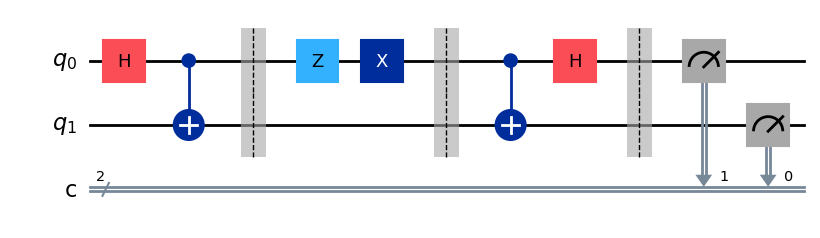

In [74]:
def superdense_circuit (bits):
    # We need 2 qubits and 2 classical bits for the result 
    qc = QuantumCircuit(2, 2)
    # STEP 0: Preparation (Entanglement)
    # Shared entanglement between Alice (q0) and Bob (q1)
    qc.h(0)
    qc.cx(0, 1)
    qc.barrier()

    # STEP 1: Alice's Encoding 
    # Alice applies gates to her qubit (q0) based on the bits
    if bits == "00":
        pass # Identity: do nothing
    elif bits == "01":
        qc.x(0) # Bit-flip
    elif bits == "10":
        qc.z(0) # Phase-flip
    elif bits == "11":
        qc.z(0)
        qc.x(0) # Both
    qc.barrier()

    # STEP 2: Transmission
    # Alice sends q0 to Bob. In the circuit, Bob now has q0 and q1.
    
    # STEP 3: Bob's Decoding
    qc.cx(0, 1)
    qc.h(0)
    qc.barrier()
    # Measurement
    qc.measure(0, 1) # Map qubit 0 to classical bit 1
    qc.measure(1, 0) # Map qubit 1 to classical bit 0
    
    return qc

# Test sending the message "11"
message = "11"
circuit = superdense_circuit(message)

# Execute on a simulator
backend = Aer.get_backend('qasm_simulator')
job = backend.run(circuit, shots=1024)
result = job.result().get_counts()

print(f"Sent: {message}")
print(f"Bob measured: {result}")
circuit.draw('mpl')